# Plots for simulations over the GP65 array, for expected fluxes of CR

In [1]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.gridspec import GridSpec

# Set default figuresize and font size and labelsize for plots
plt.rcParams['figure.figsize'] = (15, 12)
plt.rcParams['font.size'] = 25
plt.rcParams['axes.labelsize'] = 25
plt.rcParams['xtick.labelsize'] = 25
plt.rcParams['ytick.labelsize'] = 25
mpl.rcParams['mathtext.fontset'] = 'stix'
mpl.rcParams['font.family'] = 'STIXGeneral'

In [ ]:
def calculate_PAO_spectrum(e_eV):
    """
    Calculate the CR flux measured by PAO in 10 ** 17 eV < E < 10 ** 20 eV
    with the SD-750 and SD-1500.
    The formula of the spectrum is Equation (13) of
    Abreu et al., Eur. Phys. J. C 81, 966 (2021)
    (https://doi.org/10.1140/epjc/s10052-021-09700-w)
    """


    j_0 = 1.309e-18 # km^-2 yr^-1 sr^-1 eV^-1
    e_0 = 10 ** 18.5 # eV
    omega_01, omega_12, omega_23, omega_34 = 0.43, 0.05, 0.05, 0.05
    g_0, g_1, g_2, g_3, g_4 = 2.64, 3.298, 2.52, 3.08, 5.2
    e_01, e_12, e_23, e_34 = 1.24e17, 4.9e18, 1.4e19, 4.7e19 # eV

    j = j_0 * (e_eV/e_0) ** (-g_0) \
            * (1 + (e_eV/e_01) ** (1/omega_01)) ** ((g_0-g_1) * omega_01) \
            * (1 + (e_eV/e_12) ** (1/omega_12)) ** ((g_1-g_2) * omega_12) \
            * (1 + (e_eV/e_23) ** (1/omega_23)) ** ((g_2-g_3) * omega_23) \
            * (1 + (e_eV/e_34) ** (1/omega_34)) ** ((g_3-g_4) * omega_34) \
            / (1 + (e_0/e_01)  ** (1/omega_01)) ** ((g_0-g_1) * omega_01) \
            / (1 + (e_0/e_12)  ** (1/omega_12)) ** ((g_1-g_2) * omega_12) \
            / (1 + (e_0/e_23)  ** (1/omega_23)) ** ((g_2-g_3) * omega_23) \
            / (1 + (e_0/e_34)  ** (1/omega_34)) ** ((g_3-g_4) * omega_34)

    return j

name_sims = "GP300NJ"

path = f"/sps/grand/jlavoisier/code/quantification/check_sims/out_files/simsGP300NJ_theta_n_ant_energy.npy"

file_sims = np.load(path)

theta_tot = file_sims[0]
phi_tot = file_sims[1]
n_ant_trig_tot = file_sims[2]
energy_tot = file_sims[3]

log_bins_energy_tot = np.logspace(np.log10(energy_tot.min()),
                       np.log10(energy_tot.max()),
                       20)

bins_theta_tot = np.linspace(theta_tot.min(), theta_tot.max()+1, 20)

bins_phi = np.linspace(0, 360, 60)



theta = theta_tot[n_ant_trig_tot >= 5]
phi = phi_tot[n_ant_trig_tot >= 5]
energy = energy_tot[n_ant_trig_tot >= 5]

print(f"Number of events in sim {name_sims}: {len(theta_tot)}")
print(f"Number of events with at least 5 triggered antennas: {len(theta)}")

log_bins_energy = np.logspace(np.log10(energy.min()),
                       np.log10(energy.max()),
                       20)

bins_theta = np.linspace(theta.min(), theta.max()+1, 15)

for i in range(13):
    print(f"Number of events in file {i+1}: {np.sum(n_ant_trig_tot[i*2000:(i+1)*2000] >= 5)}")

Number of events in sim GP300NJ: 24993
Number of events with at least 5 triggered antennas: 3496
Number of events in file 1: 0
Number of events in file 2: 0
Number of events in file 3: 0
Number of events in file 4: 146
Number of events in file 5: 456
Number of events in file 6: 691
Number of events in file 7: 358
Number of events in file 8: 0
Number of events in file 9: 22
Number of events in file 10: 280
Number of events in file 11: 601
Number of events in file 12: 761
Number of events in file 13: 181


## 2d histogram of detected events for simulations (not folded)

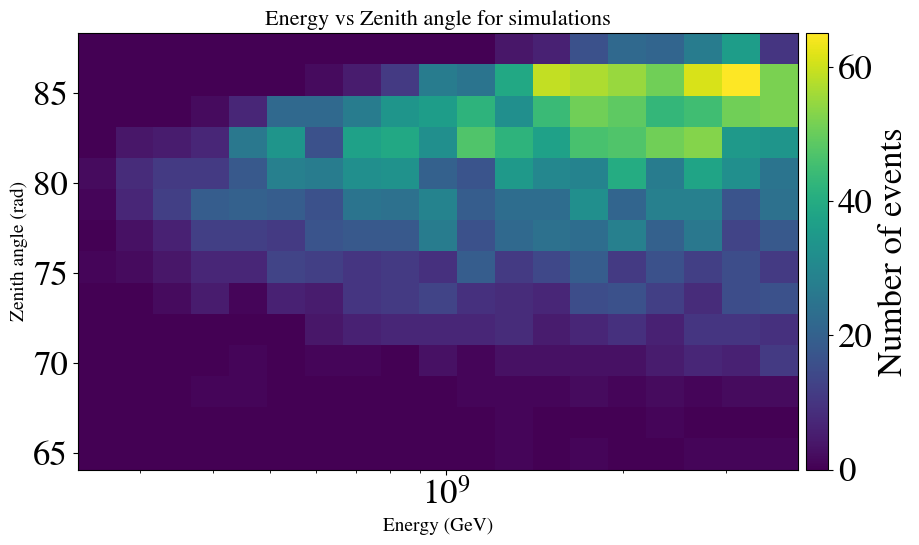

In [3]:
plt.figure(figsize=(10,6))
plt.hist2d(energy,
           theta,
           bins=(log_bins_energy, bins_theta),
           cmap=plt.cm.viridis
           )

# plt.plot(np.linspace(np.min(theta), np.max(theta), 100),
#          5*np.ones(100),
#          color='red', linestyle='--',
#          label='5 triggered antennas'
#          )
# plt.legend(loc='upper left', fontsize=12)
plt.xscale('log')
plt.colorbar(label='Number of events',
             pad=0.01)
plt.ylabel('Zenith angle (rad)',
           fontsize=14)
plt.xlabel('Energy (GeV)',
           fontsize=14)
plt.title('Energy vs Zenith angle for simulations',
          fontsize=16)

plt.tight_layout()
# plt.savefig(f"/pbs/home/j/jlavoisier/pipeline_lab/zenith_quant/plots/sims{name_sims}_theta_Energy.png")
plt.show()

## Distribution of events for all and triggered eventds

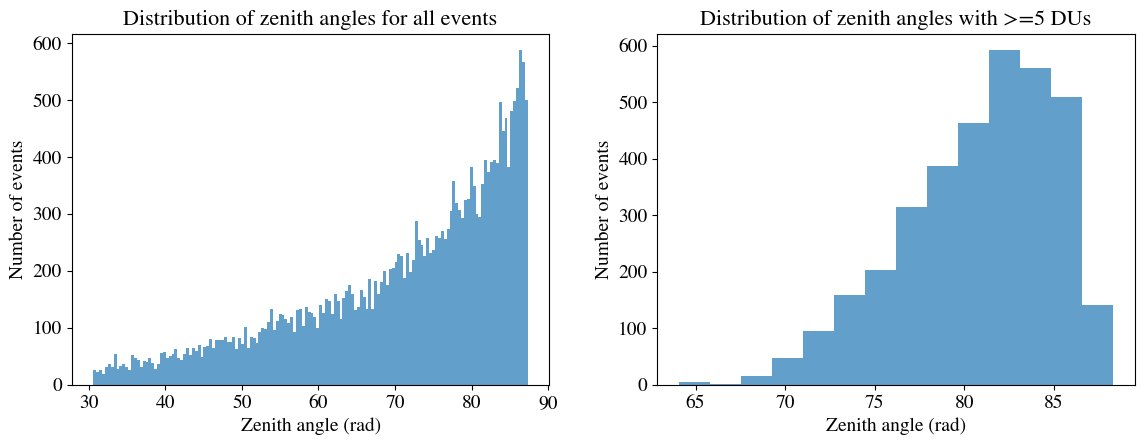

In [4]:

# Plot the distribution of zenith angles with and without 5 antenna detection in the same plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.hist(theta_tot, 
         bins=150, 
        #  color='tab.blue', 
         alpha=0.7
         )
ax1.set_xlabel('Zenith angle (rad)', 
               fontsize=14
               )
ax1.set_ylabel('Number of events', 
               fontsize=14
               )
ax1.tick_params(axis='both', labelsize=14)
ax1.set_title('Distribution of zenith angles for all events', 
              wrap=True,
              fontsize=16
              )

ax2.hist(theta, 
         bins=bins_theta,
        #  color='tab.orange', 
         alpha=0.7
         )
ax2.set_xlabel('Zenith angle (rad)', 
               fontsize=14
               )
ax2.set_ylabel('Number of events', 
               fontsize=14
               )
ax2.tick_params(axis='both', labelsize=14)
ax2.set_title('Distribution of zenith angles with >=5 DUs', 
              wrap=True,
              fontsize=16
              )

plt.tight_layout()
# plt.savefig(f"/pbs/home/j/jlavoisier/pipeline_lab/zenith_quant/plots/sims{name_sims}_theta_distrib.png")
plt.show()


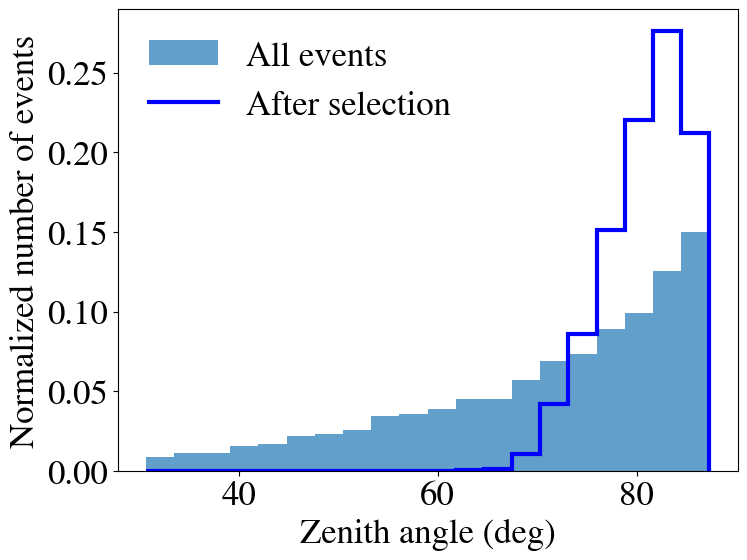

In [ ]:
plt.figure(figsize=(8,6))

theta_bins = np.linspace(theta_tot.min(), theta_tot.max(), 21)

hist_theta_all = np.histogram(theta_tot, bins=theta_bins)[0]
norm_hist_theta_all = hist_theta_all / np.sum(hist_theta_all)

plt.stairs(norm_hist_theta_all, theta_bins,
           label='All events',
           color='tab:blue',
           alpha=0.7,
           fill=True
           )

hist_theta_5ant = np.histogram(theta, bins=theta_bins)[0]
norm_hist_theta_5ant = hist_theta_5ant / np.sum(hist_theta_5ant)

plt.stairs(norm_hist_theta_5ant, theta_bins,
           label='After selection',
           color='blue',
           linewidth=3,
        #    alpha=0.7
           )
plt.legend(loc='upper left', 
        #    fontsize=14
           frameon=False
           )
plt.xlabel('Zenith angle (deg)', 
        #    fontsize=14
           )
plt.ylabel('Normalized number of events', 
        #    fontsize=14
           )
# plt.title('Distribution of zenith angles for all events and with >=5 DUs', fontsize=16)
# plt.tight_layout()
plt.savefig(f"/sps/grand/jlavoisier/code/quantification/0_plots_article/sims_zenith_distrib.pdf",
            format='pdf', 
            dpi=300, 
            bbox_inches = "tight"
            )
plt.show()

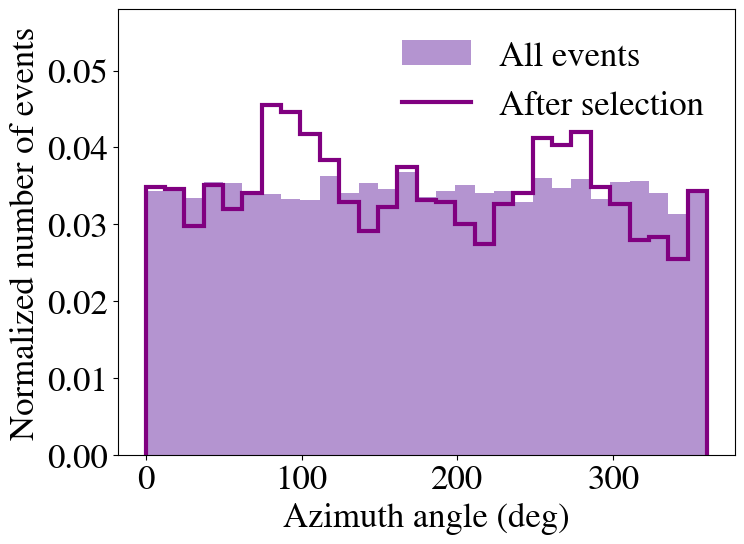

In [ ]:
plt.figure(figsize=(8,6))

phi_bins = np.linspace(phi_tot.min(), phi_tot.max(), 30)

hist_phi_all = np.histogram(phi_tot, bins=phi_bins)[0]
norm_hist_phi_all = hist_phi_all / np.sum(hist_phi_all)

plt.stairs(norm_hist_phi_all, phi_bins,
           label='All events',
           color='tab:purple',
           alpha=0.7,
           fill=True
           )

hist_phi_5ant = np.histogram(phi, bins=phi_bins)[0]
norm_hist_phi_5ant = hist_phi_5ant / np.sum(hist_phi_5ant)

plt.stairs(norm_hist_phi_5ant, phi_bins,
           label='After selection',
           color='purple',
           linewidth=3,
        #    alpha=0.7
           )
plt.legend(loc='upper right', 
        #    fontsize=14
           frameon=False
           )
plt.xlabel('Azimuth angle (deg)', 
        #    fontsize=14
           )
plt.ylabel('Normalized number of events', 
        #    fontsize=14
           )
plt.ylim(ymax=0.058)
# plt.title('Distribution of azimuth angles for all events and with >=5 DUs', fontsize=16)
plt.tight_layout()
# plt.savefig(f"/pbs/home/j/jlavoisier/pipeline_lab/zenith_quant/plots/sims{name_sims}_theta_distrib_norm.png")
plt.savefig(f"/sps/grand/jlavoisier/code/quantification/0_plots_article/sims_azimuth_distrib.pdf",
            format='pdf', 
            dpi=300, 
            bbox_inches = "tight"
            )
plt.show()

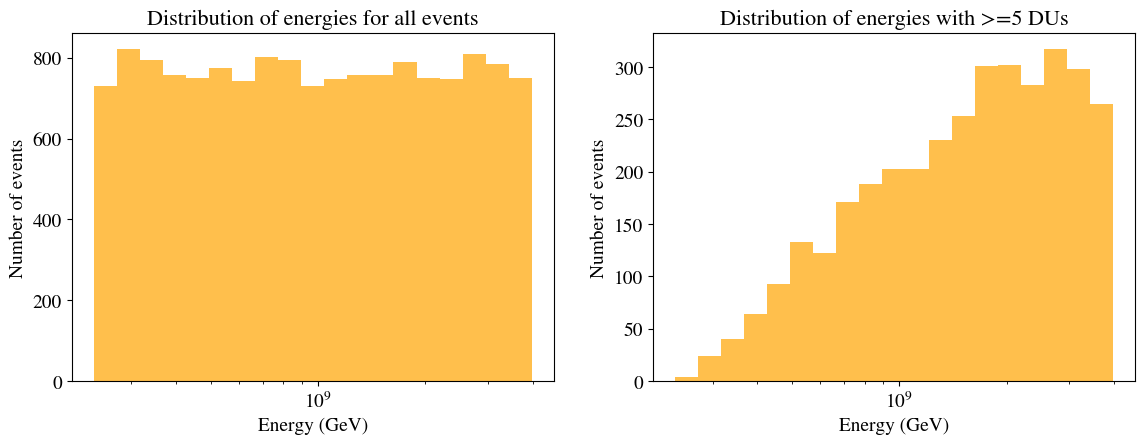

Energy range for all events: 31630000.0 - 3980600064.0 GeV
Energy range for events with >=5 DUs: 234890000.0 - 3978899968.0 GeV


In [ ]:

# Plot the distribution of energies with and without 5 antenna detection in the same plot

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.hist(energy_tot, 
         bins=log_bins_energy, 
         color='orange', 
         alpha=0.7
         )
ax1.set_xscale('log')
ax1.set_xlabel('Energy (GeV)', 
               fontsize=14
               )
ax1.set_ylabel('Number of events', 
               fontsize=14
               )
ax1.set_title('Distribution of energies for all events', 
              wrap=True,
              fontsize=16
              ) 
ax1.tick_params(axis='both', labelsize=14)
ax2.hist(energy, 
         bins=log_bins_energy,
         color='orange', 
         alpha=0.7
         )
ax2.set_xscale('log')
ax2.set_xlabel('Energy (GeV)', 
               fontsize=14
               )
ax2.set_ylabel('Number of events', 
               fontsize=14
               )
ax2.set_title('Distribution of energies with >=5 DUs', 
              wrap=True,
              fontsize=16
              )
ax2.tick_params(axis='both', labelsize=14)
plt.tight_layout()
# plt.savefig(f"/pbs/home/j/jlavoisier/pipeline_lab/zenith_quant/plots/sims{name_sims}_energy_distrib.png")
plt.show()

print(f"Energy range for all events: {energy_tot.min()} - {energy_tot.max()} GeV")
print(f"Energy range for events with >=5 DUs: {energy.min()} - {energy.max()} GeV")

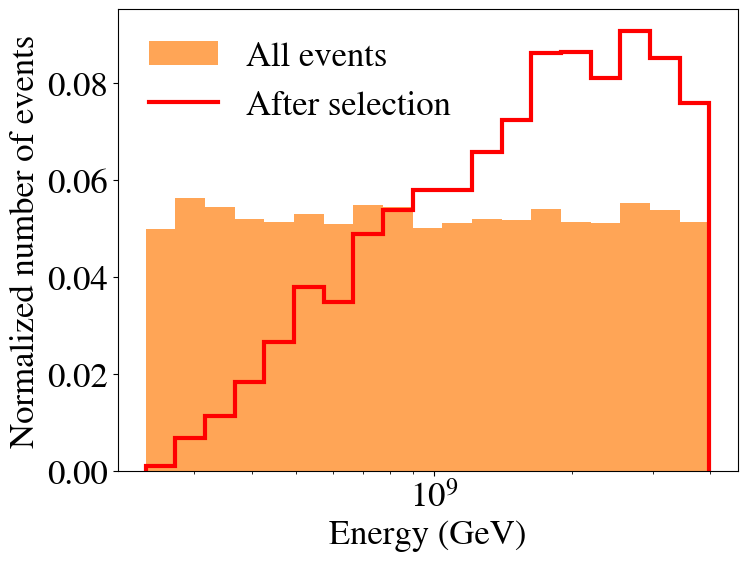

In [ ]:
plt.figure(figsize=(8,6))


hist_energy_all = np.histogram(energy_tot, bins=log_bins_energy)[0]
norm_hist_energy_all = hist_energy_all / np.sum(hist_energy_all)

plt.stairs(norm_hist_energy_all, log_bins_energy,
           label='All events',
           color='tab:orange',
           alpha=0.7,
           fill=True
           )

hist_energy_5ant = np.histogram(energy, bins=log_bins_energy)[0]
norm_hist_energy_5ant = hist_energy_5ant / np.sum(hist_energy_5ant)

plt.stairs(norm_hist_energy_5ant, log_bins_energy,
           label=r'After selection',
           color='red',
           linewidth=3,
        #    alpha=0.7
           )
plt.legend(loc='upper left', 
        #    fontsize=14
           frameon=False
           )
plt.xlabel('Energy (GeV)', 
        #    fontsize=14
           )
plt.xscale('log')
plt.ylabel('Normalized number of events', 
        #    fontsize=14
           )
# plt.title('Distribution of zenith angles for all events and with >=5 DUs', fontsize=16)
# plt.tight_layout()
# plt.savefig(f"/pbs/home/j/jlavoisier/pipeline_lab/zenith_quant/plots/sims{name_sims}_theta_distrib_norm.png")
plt.savefig(f"/sps/grand/jlavoisier/code/quantification/0_plots_article/sims_energy_distrib.pdf",
            format='pdf', 
            dpi=300, 
            bbox_inches = "tight"
            )
plt.show()

## measurement of weights (expected realistic distributions for zenith arrival and particle energy)

In [9]:

# Weights per bin
weights_per_energy_bin = np.zeros(len(log_bins_energy)-1)
for i in range(len(log_bins_energy)-1):
    energy_i = (log_bins_energy[i] + log_bins_energy[i+1]) / 2
    weights_per_energy_bin[i] = calculate_PAO_spectrum(energy_i * 1e9) # The weight for the energy bin

weights_per_theta_bin = np.zeros(len(bins_theta)-1)
for i in range(len(bins_theta)-1):
    theta_i = (bins_theta[i] + bins_theta[i+1]) / 2
    weights_per_theta_bin[i] = np.cos(np.deg2rad(theta_i)) * np.sin(np.deg2rad(theta_i)) # The weight for the zenith angle bin

weights_tab = np.matmul(weights_per_energy_bin.reshape(-1, 1), weights_per_theta_bin.reshape(1, -1)) # The total weight for each bin is the product of the energy and zenith angle weights


hist_theta_tot = np.histogram(theta_tot, bins=bins_theta)[0]
hist_energy_tot = np.histogram(energy_tot, bins=log_bins_energy)[0]

weights_tab_events = np.matmul(hist_energy_tot.reshape(-1, 1), hist_theta_tot.reshape(1, -1)) # The number of events in each bin is the product of the number of events in the energy and zenith angle bins


weights = weights_tab / weights_tab_events # The weight for each bin is the total weight for the bin divided by the number of events in the bin, to avoid over-representing bins with more events


In [10]:


from scipy.integrate import trapz

clem_weights_trigg = calculate_PAO_spectrum(energy * 1e9) * np.cos(np.deg2rad(theta)) * np.sin(np.deg2rad(theta))
clem_weights_all = calculate_PAO_spectrum(energy_tot * 1e9) * np.sin(np.deg2rad(theta_tot))


clem_hist_trigg = np.histogram(energy, bins=log_bins_energy, weights=clem_weights_trigg)[0]
clem_hist_all = np.histogram(energy_tot, bins=log_bins_energy, weights=clem_weights_all)[0]

total_surface = (11.3 - (-5.2)) * (6.5 - (-4.5)) * 1e6 # in m^2
# total_time = 846672 # in s
total_time = 34.4*24*3600 # in seconds

clem_hist_trigg_2d = np.histogram2d(energy*1e9, 
                                    theta, 
                                    bins=(log_bins_energy, bins_theta), 
                                    weights=clem_weights_trigg)[0]
clem_hist_all_2d = np.histogram2d(energy_tot*1e9, 
                                    theta_tot,
                                    bins=(log_bins_energy, bins_theta),
                                    weights=clem_weights_all)[0]

clem_efficiency_2d = np.nan_to_num(clem_hist_trigg_2d / clem_hist_all_2d) # what about when hist_all_2d is 0 : set the value to 0

mid_bins_energy = (log_bins_energy[:-1] + log_bins_energy[1:]) / 2
mid_bins_zenith = (bins_theta[:-1] + bins_theta[1:]) / 2
exposure_E = 2 * np.pi * total_time * total_surface * trapz(np.sin(mid_bins_zenith)[None, :] * clem_efficiency_2d, mid_bins_zenith)
exposure_theta = 2 * np.pi * total_time * total_surface * trapz(clem_efficiency_2d, mid_bins_energy, axis = 0)

exposure = clem_hist_trigg / clem_hist_all * total_time * 2 * np.pi * (-np.cos(np.max(theta*np.pi/180)) + np.cos(np.min(theta*np.pi/180))) * total_surface # in m^2 s sr

print(np.min(theta))

years_to_s = 365.25 * 24 * 3600

auger_integrated = trapz(calculate_PAO_spectrum(mid_bins_energy*1e9), mid_bins_energy*1e9) * 1e-6 / years_to_s # in s and m^2

print("N_CR:",  trapz(calculate_PAO_spectrum(mid_bins_energy*1e9) * exposure, mid_bins_energy*1e9) * 1e-6 / years_to_s )
print("N_CR2:",  trapz(calculate_PAO_spectrum(mid_bins_energy*1e9) * exposure_E, mid_bins_energy*1e9) * 1e-6 / years_to_s )

64.06999969482422
N_CR: 390.4640187427923
N_CR2: 0.0


/scratch/users/j/jlavoisier/ipykernel_1273451/2092817622.py:23: RuntimeWarning: invalid value encountered in divide
  clem_efficiency_2d = np.nan_to_num(clem_hist_trigg_2d / clem_hist_all_2d) # what about when hist_all_2d is 0 : set the value to 0
/scratch/users/j/jlavoisier/ipykernel_1273451/2092817622.py:27: DeprecationWarning: 'scipy.integrate.trapz' is deprecated in favour of 'scipy.integrate.trapezoid' and will be removed in SciPy 1.14.0
  exposure_E = 2 * np.pi * total_time * total_surface * trapz(np.sin(mid_bins_zenith)[None, :] * clem_efficiency_2d, mid_bins_zenith)
/scratch/users/j/jlavoisier/ipykernel_1273451/2092817622.py:28: DeprecationWarning: 'scipy.integrate.trapz' is deprecated in favour of 'scipy.integrate.trapezoid' and will be removed in SciPy 1.14.0
  exposure_theta = 2 * np.pi * total_time * total_surface * trapz(clem_efficiency_2d, mid_bins_energy, axis = 0)
/scratch/users/j/jlavoisier/ipykernel_1273451/2092817622.py:36: DeprecationWarning: 'scipy.integrate.trapz'

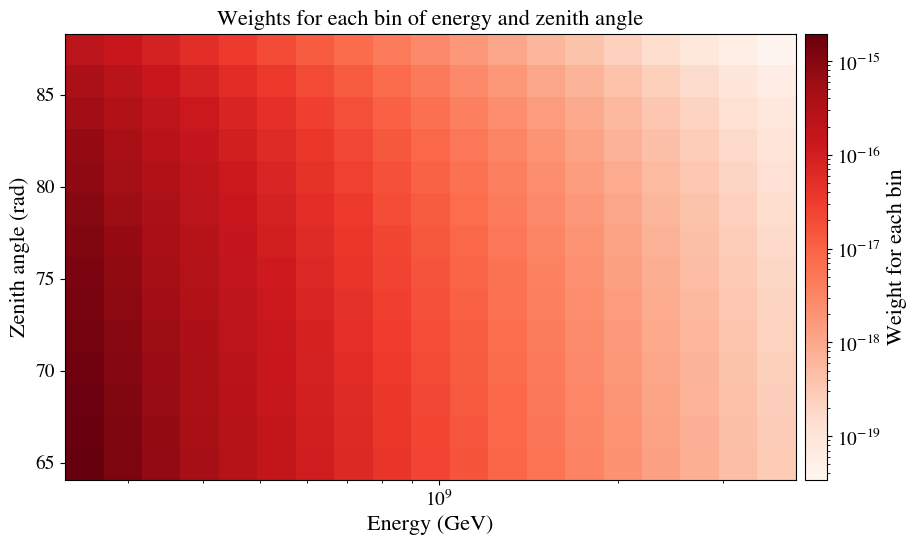

In [ ]:
# Plot the weights in pcolormesh
if True:
    fig, ax = plt.subplots(figsize=(10, 6))
    X, Y = np.meshgrid(log_bins_energy, bins_theta)
    im = ax.pcolormesh(X, 
                    Y, 
                    weights_tab.T, 
                    cmap="Reds",
                    norm=mpl.colors.LogNorm(vmin=weights_tab.min(), vmax=weights_tab.max())
                    )
    ax.set_xscale('log')
    cbar = plt.colorbar(im, pad=0.01)
    cbar.ax.tick_params(labelsize=14)
    cbar.set_label(label='Weight for each bin',
                size=16,
                #    weight='bold'
                )
    ax.set_xlabel('Energy (GeV)',
            fontsize=16)
    ax.set_ylabel('Zenith angle (rad)',
            fontsize=16)
    ax.tick_params(axis='both', labelsize=14)
    ax.set_title('Weights for each bin of energy and zenith angle',
            wrap=True,
            fontsize=16)
    plt.tight_layout()
    # plt.savefig(f"/pbs/home/j/jlavoisier/pipeline_lab/zenith_quant/plots/sims{name_sims}_weights_tab.png")
    plt.show()


## Reweighted parameters

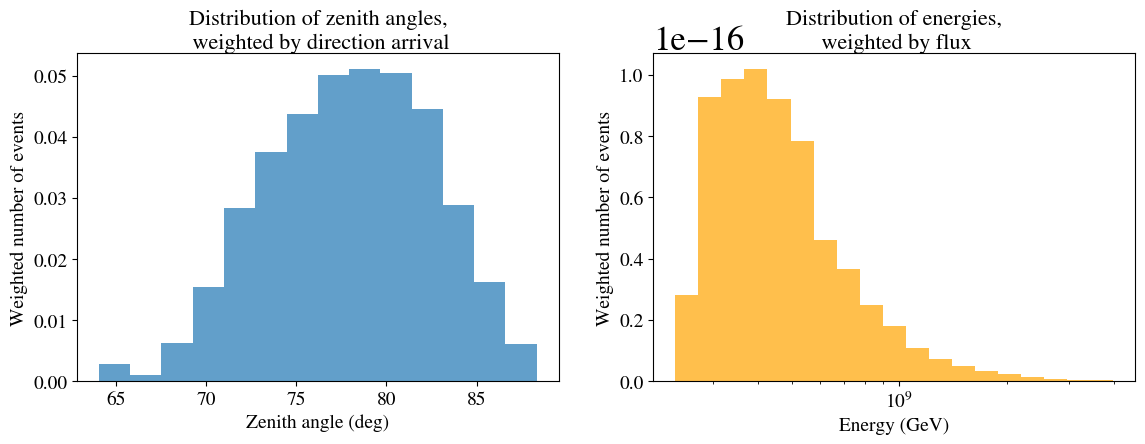

In [12]:
# Plot distribution of theta and energy distributions reweighted
if True:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    hist_theta = np.histogram(theta, bins=bins_theta)[0]
    hist_energy = np.histogram(energy, bins=log_bins_energy)[0]
    ax1.stairs(hist_theta * weights_per_theta_bin / hist_theta_tot, # The weight for each bin is the total weight for the bin divided by the number of events in the bin, to avoid over-representing bins with more events
            edges=bins_theta,
            fill=True,
            alpha=0.7
            )
    ax1.set_xlabel('Zenith angle (deg)', 
                fontsize=14
                )
    ax1.set_ylabel('Weighted number of events', 
                fontsize=14
                )
    ax1.tick_params(axis='both', labelsize=14)
    ax1.set_title('Distribution of zenith angles,\n weighted by direction arrival', 
                wrap=True,
                fontsize=16
                )
    ax2.stairs(hist_energy * weights_per_energy_bin / hist_energy_tot, # The weight for each bin is the total weight for the bin divided by the number of events in the bin, to avoid over-representing bins with more events
            edges=log_bins_energy, 
            fill=True,
            color='orange',
            alpha=0.7
            )
    ax2.set_xscale('log')
    ax2.set_xlabel('Energy (GeV)', 
                fontsize=14
                )
    ax2.set_ylabel('Weighted number of events', 
                fontsize=14
                )
    ax2.set_title('Distribution of energies,\n weighted by flux', 
                wrap=True,
                fontsize=16
                )
    ax2.tick_params(axis='both', labelsize=14)
    plt.tight_layout()
    plt.savefig(f"/pbs/home/j/jlavoisier/pipeline_lab/zenith_quant/plots/sims{name_sims}_theta_energy_distrib_weighted.png")
    plt.show()


    np.save(f"/pbs/home/j/jlavoisier/pipeline_lab/check_sims/sims{name_sims}_energy_dens.npy", 
            [hist_energy * weights_per_energy_bin / hist_energy_tot])
    np.save(f"/pbs/home/j/jlavoisier/pipeline_lab/check_sims/sims{name_sims}_energy_bins.npy", 
            [log_bins_energy])
    np.save(f"/pbs/home/j/jlavoisier/pipeline_lab/check_sims/sims{name_sims}_theta_dens.npy", 
            [hist_theta * weights_per_theta_bin / hist_theta_tot])
    np.save(f"/pbs/home/j/jlavoisier/pipeline_lab/check_sims/sims{name_sims}_theta_bins.npy", 
            [bins_theta])

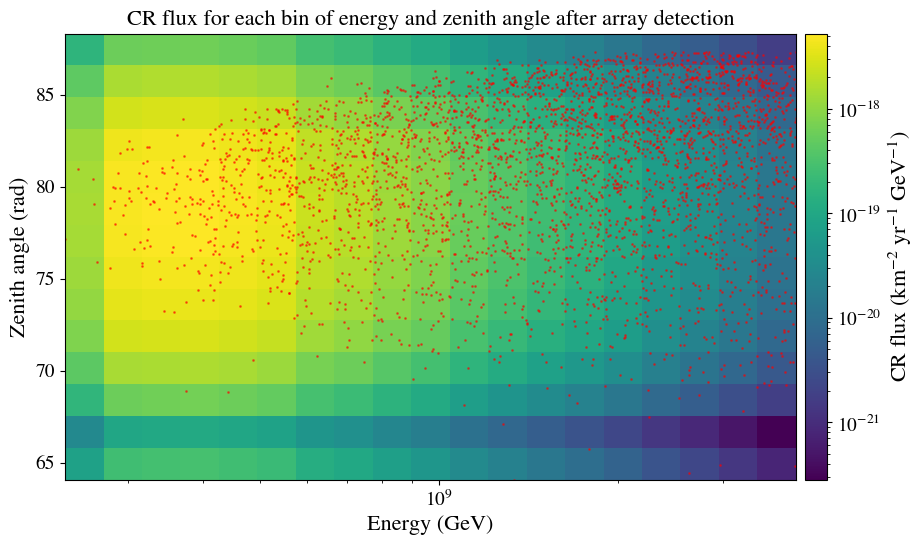

In [ ]:
hist_theta = np.histogram(theta, bins=bins_theta)[0]
hist_energy = np.histogram(energy, bins=log_bins_energy)[0]

weights_tab_trigevents = np.matmul(hist_energy.reshape(-1, 1), hist_theta.reshape(1, -1)) # The number of events in each bin is the product of the number of events in the energy and zenith angle bins


folded_events = weights_tab_trigevents * weights # The weight for each bin is the total weight for the bin divided by the number of events in the bin, to avoid over-representing bins with more events

np.save(f"/pbs/home/j/jlavoisier/pipeline_lab/check_sims/sims{name_sims}_folded_events.npy", 
            [folded_events])

# Plot folded number of events withpcolormesh
if True:
    fig, ax = plt.subplots(figsize=(10, 6))
    X, Y = np.meshgrid(log_bins_energy, bins_theta)
    im = ax.pcolormesh(X, 
                    Y, 
                    folded_events.T, 
                    cmap="viridis",
                    norm=mpl.colors.LogNorm(vmin=folded_events.min(), vmax=folded_events.max())
                    )
    ax.set_xscale('log')
    plt.scatter(energy, theta, s=1, color='red', alpha=0.5, label='Events with >=5 DUs')
    cbar = plt.colorbar(im, pad=0.01)
    cbar.ax.tick_params(labelsize=14)
    cbar.set_label(label=r'CR flux (km$^{-2}$ yr$^{-1}$ GeV$^{-1}$)',
                size=16,
                #    weight='bold'
                )
    ax.set_xlabel('Energy (GeV)',
            fontsize=16)
    ax.set_ylabel('Zenith angle (rad)',
            fontsize=16)
    ax.tick_params(axis='both', labelsize=14)
    ax.set_title('CR flux for each bin of energy and zenith angle after array detection',
            wrap=True,
            fontsize=16)
    plt.tight_layout()
    # plt.savefig(f"/pbs/home/j/jlavoisier/pipeline_lab/zenith_quant/plots/sims{name_sims}_folded_events.png")
    plt.show()


## Polar plot of expected flux per zenith and azimuth bin

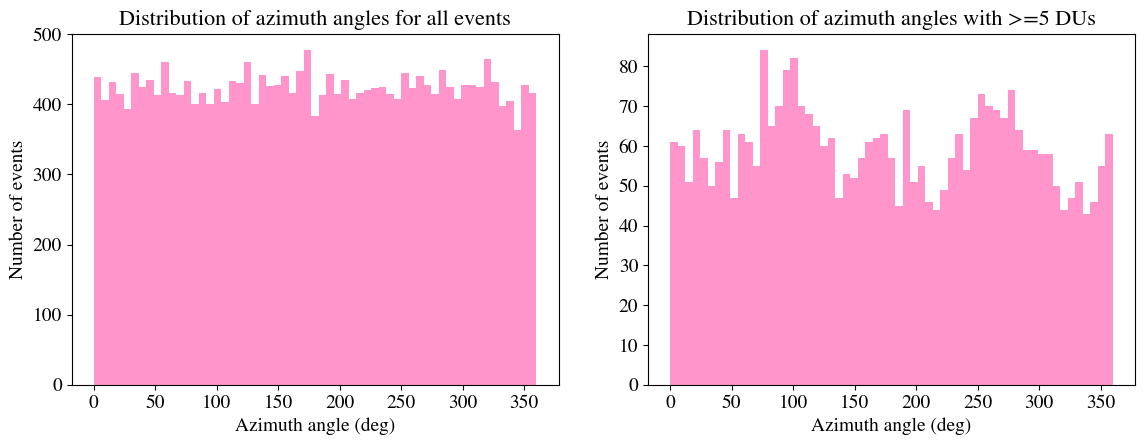

In [ ]:

# Plot the distribution of zenith angles with and without 5 antenna detection in the same plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.hist(phi_tot, 
         bins=bins_phi, 
         color='hotpink', 
         alpha=0.7
         )
ax1.set_xlabel('Azimuth angle (deg)', 
               fontsize=14
               )
ax1.set_ylabel('Number of events', 
               fontsize=14
               )
ax1.tick_params(axis='both', labelsize=14)
ax1.set_title('Distribution of azimuth angles for all events', 
              wrap=True,
              fontsize=16
              )

ax2.hist(phi, 
         bins=bins_phi,
         color='hotpink',
         alpha=0.7
         )
ax2.set_xlabel('Azimuth angle (deg)', 
               fontsize=14
               )
ax2.set_ylabel('Number of events', 
               fontsize=14
               )
ax2.tick_params(axis='both', labelsize=14)
ax2.set_title('Distribution of azimuth angles with >=5 DUs', 
              wrap=True,
              fontsize=16
              )

plt.tight_layout()
# plt.savefig(f"/pbs/home/j/jlavoisier/pipeline_lab/zenith_quant/plots/sims{name_sims}_phi_distrib.png")
plt.show()


In [15]:
weights_per_phi_bin = np.ones(len(bins_phi)-1)
weights_polar = np.matmul(weights_per_phi_bin.reshape(-1, 1), weights_per_theta_bin.reshape(1, -1)) 
# The total weight for each bin is the product of the energy and zenith angle weights


hist_phi_tot = np.histogram(phi_tot, bins=bins_phi)[0]
weights_polar_events = np.matmul(hist_phi_tot.reshape(-1, 1), hist_theta_tot.reshape(1, -1)) 
# The number of events in each bin is the product of the number of events in the energy and zenith angle bins

weights_2 = weights_polar / weights_polar_events 
# The weight for each bin is the total weight for the bin divided by the number of events in the bin, to avoid over-representing bins with more events


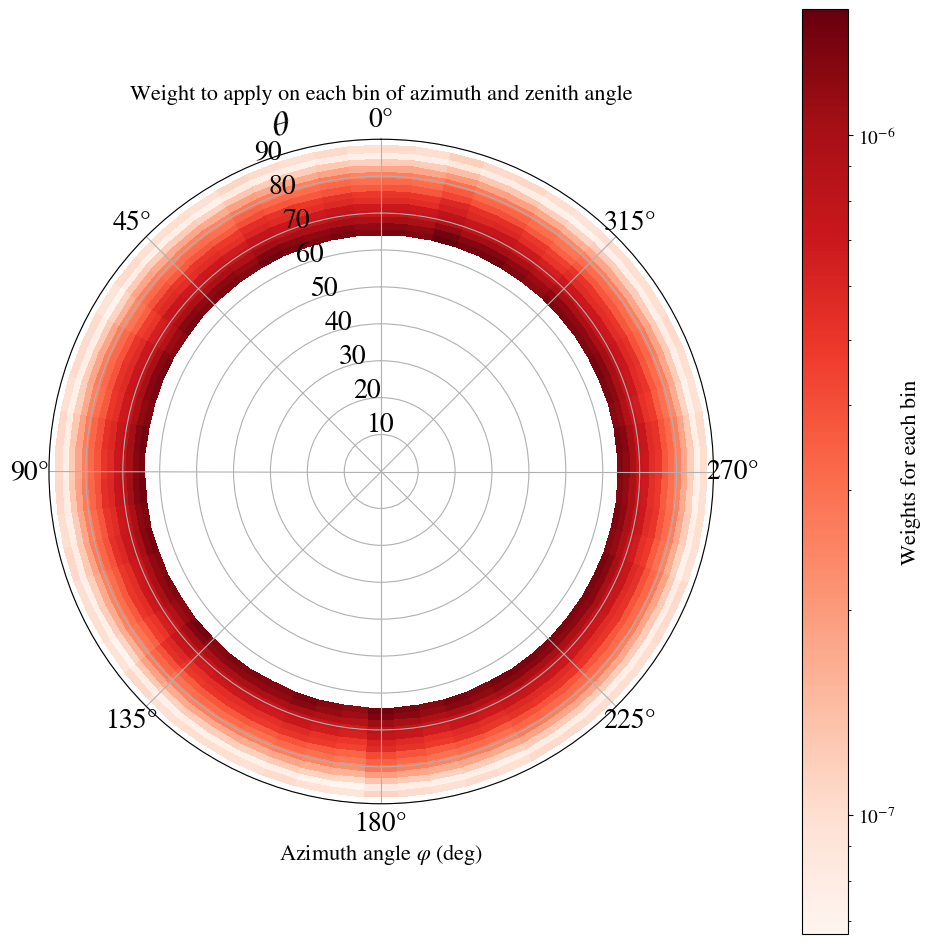

In [ ]:
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(projection='polar')

X, Y = np.meshgrid(bins_phi, bins_theta)
im = ax.pcolormesh(np.deg2rad(X), 
                   Y, 
                   weights_2.T, 
                   cmap="Reds", 
                   norm=mpl.colors.LogNorm(vmin=weights_2.min(), vmax=weights_2.max())
                   )
cbar = plt.colorbar(im, pad=0.1)
cbar.ax.tick_params(labelsize=14)
cbar.set_label(label='Weights for each bin',
                size=16,
                #    weight='bold'
                )
ax.set_xlabel(r'Azimuth angle $\varphi$ (deg)',
               fontsize=16)

ax.text(0.35, 1.02, r'$\theta$', transform=ax.transAxes,
        ha='center', va='center', rotation=15, rotation_mode='anchor',
        fontsize=25)
ax.tick_params(axis='both', 
                  labelsize=20)

ax.set_theta_zero_location("N")
ax.set_ylim(0,90)
ax.set_title('Weight to apply on each bin of azimuth and zenith angle',
            wrap=True,
            fontsize=16)
plt.tight_layout()
# plt.savefig(f"/pbs/home/j/jlavoisier/pipeline_lab/zenith_quant/plots/sims{name_sims}_weights_polar.png")
plt.show()

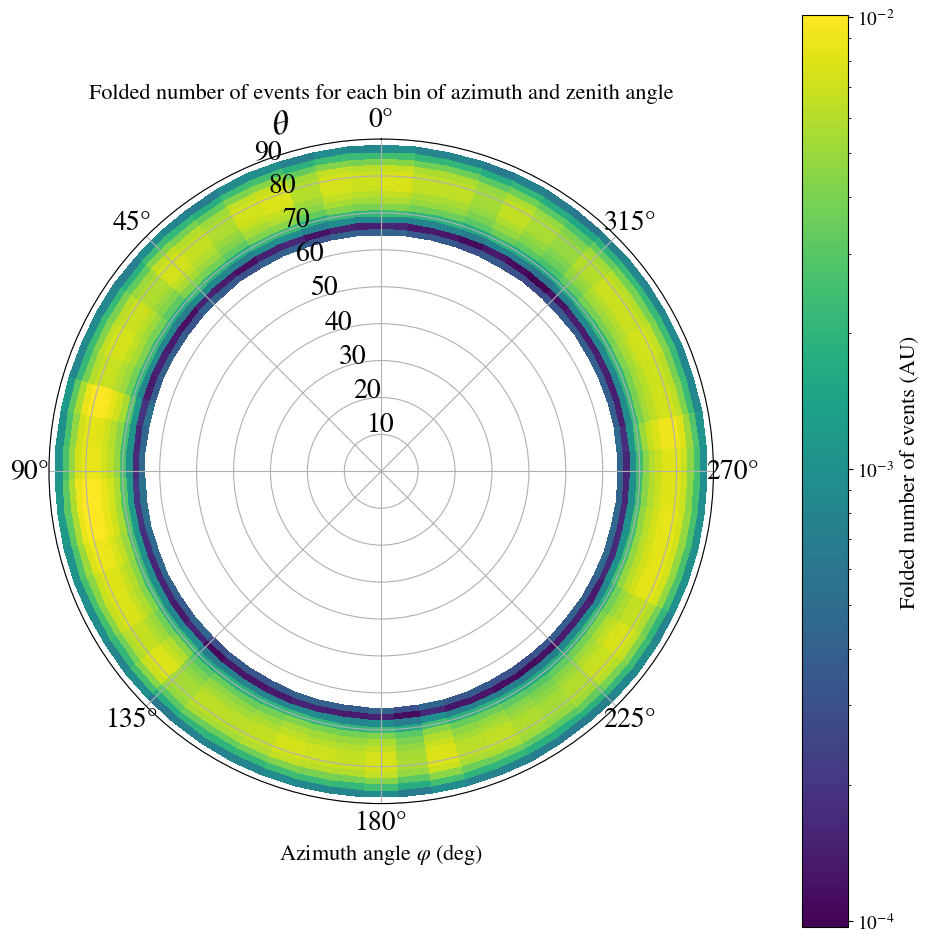

In [ ]:
hist_theta = np.histogram(theta, bins=bins_theta)[0]
hist_phi = np.histogram(phi, bins=bins_phi)[0]

weights_polar_trigevents = np.matmul(hist_phi.reshape(-1, 1), hist_theta.reshape(1, -1)) # The number of events in each bin is the product of the number of events in the azimuth and zenith angle bins


folded_events_polar = weights_polar_trigevents * weights_2 # The weight for each bin is the total weight for the bin divided by the number of events in the bin, to avoid over-representing bins with more events


fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(projection='polar')

X, Y = np.meshgrid(bins_phi, bins_theta)
im = ax.pcolormesh(np.deg2rad(X), 
                   Y, 
                   folded_events_polar.T, 
                   cmap="viridis", 
                   norm=mpl.colors.LogNorm(vmin=folded_events_polar.min(), vmax=folded_events_polar.max())
                   )
cbar = plt.colorbar(im, pad=0.1)
cbar.ax.tick_params(labelsize=14)
cbar.set_label(label='Folded number of events (AU)',
                size=16,
                #    weight='bold'
                )
ax.set_xlabel(r'Azimuth angle $\varphi$ (deg)',
               fontsize=16)

ax.text(0.35, 1.02, r'$\theta$', transform=ax.transAxes,
        ha='center', va='center', rotation=15, rotation_mode='anchor',
        fontsize=25)
ax.tick_params(axis='both', 
                  labelsize=20)

ax.set_theta_zero_location("N")
ax.set_ylim(0,90)
ax.set_title('Folded number of events for each bin of azimuth and zenith angle',
            wrap=True,
            fontsize=16)
plt.tight_layout()
# plt.savefig(f"/pbs/home/j/jlavoisier/pipeline_lab/zenith_quant/plots/sims{name_sims}_folded_events_polar.png")
plt.show()

# Getting histogram to build distributions

[0.00728423 0.00267579 0.01629689 0.04028753 0.07401315 0.09803872
 0.11435305 0.13110406 0.13385986 0.1318836  0.11648309 0.07530013
 0.04247634 0.01594356]
[64.06999969 65.80285699 67.53571429 69.26857158 71.00142888 72.73428617
 74.46714347 76.20000076 77.93285806 79.66571535 81.39857265 83.13142994
 84.86428724 86.59714454 88.33000183]
[77.23583843]


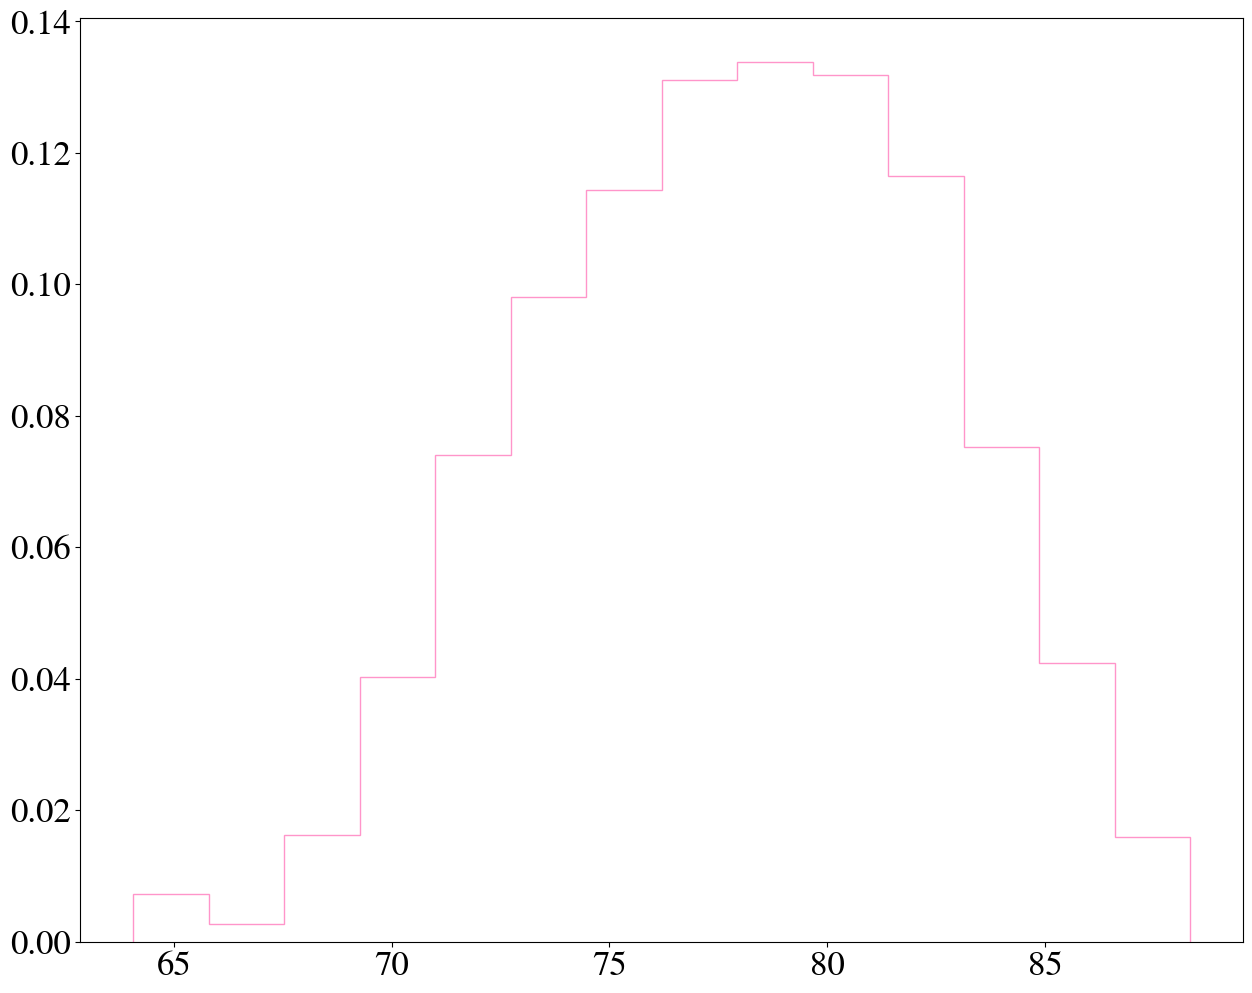

In [18]:
prob_dens_theta = hist_theta * weights_per_theta_bin / hist_theta_tot
prob_dens_theta /= np.sum(prob_dens_theta) # Normalize the distribution to get a probability density function

print(prob_dens_theta)
print(bins_theta)

plt.stairs(prob_dens_theta, 
         edges=bins_theta, 
         color='hotpink', 
         alpha=0.7
         )


# Generate random bin indices
bin_indices = np.random.choice(len(bins_theta)-1, size=1, p=prob_dens_theta)

# Map bin indices to actual values (e.g., midpoint of each bin)
rand_theta = np.random.uniform(low=bins_theta[bin_indices], high=bins_theta[bin_indices + 1])
print(rand_theta)